In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Cargamos y visualizamos los datos

In [48]:
# importamos el Dataset
import pandas as pd

# Al estar en la misma carpeta, solo necesitamos el nombre
path_local = "data/elnino.csv"

# 1. Definimos la lista con los nombres oficiales en minúsculas
columnas_minuscula = [
    'observation', 'year', 'month', 'day', 'date', 
    'latitude', 'longitude', 'zonal_winds', 'meridional_winds', 
    'humidity', 'air_temp', 'sst'
]

# 2. Leemos el archivo aplicando la nueva lista en minúsculas
df = pd.read_csv(
    path_local, 
    sep=',', 
    names=columnas_minuscula, 
    header=None, 
    skiprows=1
)

# Vamos a ver la forma del dataset para entender cuántas filas y columnas tenemos
dfshape = df.shape
print(f"El dataset tiene {dfshape[0]} filas y {dfshape[1]} columnas.")

# 3. Comprobamos la estructura
df.info()

El dataset tiene 178080 filas y 12 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 178080 entries, 0 to 178079
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   observation       178080 non-null  int64  
 1   year              178080 non-null  int64  
 2   month             178080 non-null  int64  
 3   day               178080 non-null  int64  
 4   date              178080 non-null  int64  
 5   latitude          178080 non-null  float64
 6   longitude         178080 non-null  float64
 7   zonal_winds       178080 non-null  str    
 8   meridional_winds  178080 non-null  str    
 9   humidity          178080 non-null  str    
 10  air_temp          178080 non-null  str    
 11  sst               178080 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 19.4 MB


In [49]:
# Vamos a ver la forma del dataset para entender cuántas filas y columnas tenemos
dfshape = df.shape
print(f"El dataset tiene {dfshape[0]} filas y {dfshape[1]} columnas.")

El dataset tiene 178080 filas y 12 columnas.


In [50]:
# Finalmente, un conteo de valores nulos por columna nos ayudará a identificar si necesitamos hacer limpieza de datos antes de entrenar nuestros modelos
print(df.isnull().sum())
df.head()

observation         0
year                0
month               0
day                 0
date                0
latitude            0
longitude           0
zonal_winds         0
meridional_winds    0
humidity            0
air_temp            0
sst                 0
dtype: int64


,observation,year,month,day,date,latitude,longitude,zonal_winds,meridional_winds,humidity,air_temp,sst
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [51]:
df.dtypes

observation           int64
year                  int64
month                 int64
day                   int64
date                  int64
latitude            float64
longitude           float64
zonal_winds             str
meridional_winds        str
humidity                str
air_temp                str
sst                     str
dtype: object

# Limpiamos y formateamos los datos

In [52]:
# 1. Eliminar duplicados si los hay
df = df.drop_duplicates()

# 2. Reemplazamos los puntos aislados por valores nulos reales (NaN)
df = df.replace('.', np.nan)

# 3. Creamos una fecha real combinando las columnas de año, mes y día
df['complete_date'] = pd.to_datetime(
    (df['year'] + 1900).astype(str) + '-' + 
    df['month'].astype(str) + '-' + 
    df['day'].astype(str)
)

# 4. Reemplazamos la antigua columna 'date' por esta nueva con el formato correcto
df['date'] = df['complete_date'].dt.strftime('%Y-%m-%d')

# 5. Forzamos a que las columnas físicas sean numéricas
columnas_numericas = ['latitude', 'longitude', 'zonal_winds', 'meridional_winds', 'sst']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [53]:
df.dtypes

observation                  int64
year                         int64
month                        int64
day                          int64
date                           str
latitude                   float64
longitude                  float64
zonal_winds                float64
meridional_winds           float64
humidity                       str
air_temp                       str
sst                        float64
complete_date       datetime64[us]
dtype: object

Hipótesis de trabajo:
El aumento de la temperatura superficial del mar (SST) junto con variaciones extremas de los vientos asociados a eventos de El Niño aleja a ciertas especies marinas comerciales de sus zonas habituales de captura.

Objetivo:
Crear un Dashboard de datos históricos sobre variaciones del viento y la temperatura del Pacífico para ayudar a empresas vulnerables al clima (como pesqueras y aseguradoras marítimas) a anticipar pérdidas y gestionar sus riesgos operativos.

In [61]:
# Lista de columnas a eliminar 
columnas_a_eliminar = ['date', 'day', 'year', 'month', 'humidity', 'air_temp']

df = df.drop(columns=columnas_a_eliminar, errors='ignore')

In [62]:
#  Guardar el archivo definitivo para los modelos
df.to_csv('dataset_elnino_final.csv', index=False)

print("✅ Archivo 'dataset_elnino_final.csv' creado con éxito.")
print(f"📊 Shape final: {df.shape}")
print(f"📋 Columnas resultantes: {list(df.columns)}")

✅ Archivo 'dataset_elnino_final.csv' creado con éxito.
📊 Shape final: (178080, 9)
📋 Columnas resultantes: ['complete_date', 'latitude', 'longitude', 'zonal_winds', 'meridional_winds', 'sst_today', 'sst_avg_fortnight', 'wind_max_fortnight', 'avg_zonal_wind_15d']


In [63]:
# visualización de la tabla que hemos creado con SQL (notebook: sql_to_python) para el análisis exploratorio de datos (EDA)
# Volver a cargar el archivo para actualizar los datos en la memoria de este notebook
df = pd.read_csv('data/table_atmospheric_oceanic_dataset.csv')

# Comprobar que aparecen las nuevas variables temporales
df.head()

,complete_date,latitude,longitude,zonal_winds,meridional_winds,sst_today,sst_avg_fortnight,wind_max_fortnight,avg_zonal_wind_15d
0,1980-03-07,-0.02,-109.46,-6.8,0.7,26.24,26.240,-6.8,-6.80
1,1980-03-08,-0.02,-109.46,-4.9,1.1,25.97,26.105,-4.9,-5.85
2,1980-03-09,-0.02,-109.46,-4.5,2.2,25.28,25.830,-4.5,-5.40
3,1980-03-10,-0.02,-109.46,-3.8,1.9,24.31,25.450,-3.8,-5.00
4,1980-03-11,-0.02,-109.46,-4.2,1.5,23.19,24.998,-3.8,-4.84


In [64]:
df.shape

(178080, 9)

Variables seleccionadas para EDA:

- sst_today (temperatura superficial del mar del día actual) por coordenada
- sst_avg_fortnight (promedio de temperatura de los últimos 14 días) por coordenada
- wind_max_fortnight (viento máximo de los últimos 14 días) por coordenada
- avg_zonal_wind_15d (viento promedio de los últimos 14 días) por coordenada



Realizamos un informe estadístico descriptivo de las variables clave para entender su distribución, tendencia central y dispersión, lo que nos ayudará a identificar patrones o anomalías en los datos relacionados con el viento y la temperatura del Pacífico, fundamentales para nuestro análisis de eventos de El Niño.

In [65]:
# Resumen estadístico descriptivo de las variables clave 
# Carga del dataset desde la carpeta data
df_oceanico = pd.read_csv('data/table_atmospheric_oceanic_dataset.csv')


# Definimos la función aceptando el dataframe como argumento genérico 'df'
def generar_estadistica_descriptiva(df: pd.DataFrame) -> None:
    
    print("=== ESTADÍSTICA DESCRIPTIVA DEL DATASET PURE ===")

    variables_clave = [
        'sst_today',
        'sst_avg_fortnight',
        'zonal_winds',
        'wind_max_fortnight',
        'meridional_winds',
    ]

    # Usamos el argumento 'df' que entra a la función
    resumen_estadistico = df[variables_clave].describe().round(2)

    print(resumen_estadistico)
    print("\n" + "=" * 60 + "\n")


# Llamamos a la función pasándole nuestra variable cargada
generar_estadistica_descriptiva(df_oceanico)


=== ESTADÍSTICA DESCRIPTIVA DEL DATASET PURE ===
       sst_today  sst_avg_fortnight  zonal_winds  wind_max_fortnight  \
count  161073.00          162861.00    152917.00           155601.00   
mean       27.72              27.71        -3.30               -1.64   
std         2.06               2.04         3.37                3.76   
min        17.35              17.68       -12.40              -11.10   
25%        26.77              26.76        -5.80               -4.50   
50%        28.29              28.29        -4.00               -2.30   
75%        29.23              29.23        -1.40                0.80   
max        31.26              31.25        14.30               14.30   

       meridional_winds  
count         152918.00  
mean               0.25  
std                3.00  
min              -11.60  
25%               -1.70  
50%                0.30  
75%                2.30  
max               13.00  




Temperatura media del agua bastante alta en los últimos 14 días (mean: sst_avg_fortnight = 27.71) y también de manera general (mean: sst_today = 27.72), lo que podría indicar un evento de El Niño, algo que también las temperaturas máximas alcanzadas (31.26, 31.25). Sin embargo, es importante considerar otros factores como el viento para confirmar esta hipótesis. 
Si tenemos en cuenta el hecho de que la media de zonal_winds sea negativa (-3.30), un brusco cambio hacia valores positivos (max: zonal_winds = 14.30) podría indicar un cambio en los patrones de viento asociados a El Niño.

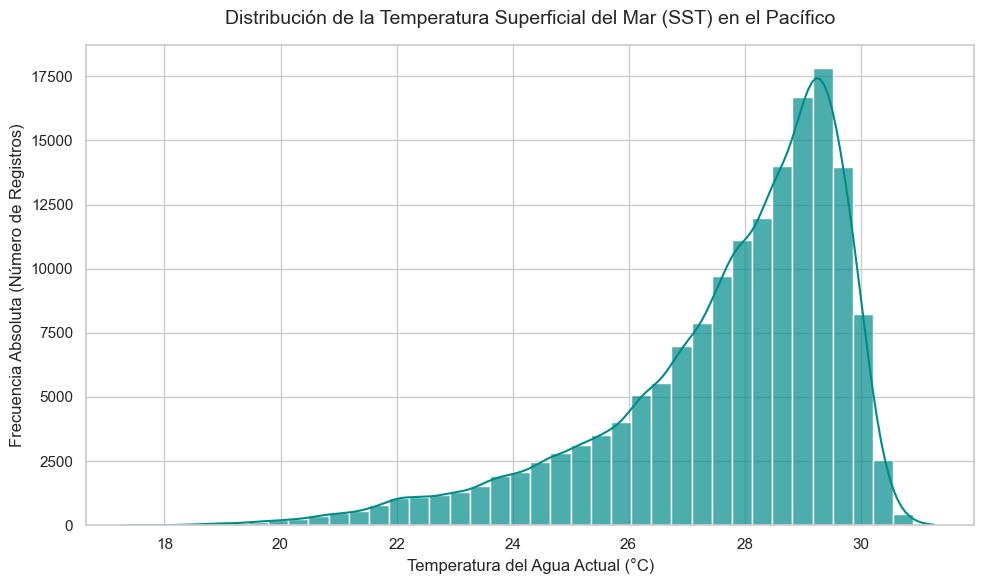

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset puro
df_oceanico = pd.read_csv("data/table_atmospheric_oceanic_dataset.csv")

# 2. Configurar el estilo visual moderno
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Dibujar el histograma con curva de densidad (KDE)
sns.histplot(
    data=df_oceanico,
    x="sst_today",
    kde=True,
    color="darkcyan",
    bins=40,
    alpha=0.7,
)

# 4. Añadir etiquetas académicas claras en español
plt.title(
    "Distribución de la Temperatura Superficial del Mar (SST) en el Pacífico",
    fontsize=14,
    pad=15,
)
plt.xlabel("Temperatura del Agua Actual (°C)", fontsize=12)
plt.ylabel("Frecuencia Absoluta (Número de Registros)", fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

"El histograma muestra una clara asimetría negativa en la Temperatura Superficial del Mar (SST). El núcleo de las observaciones se concentra en un rango cálido de entre 28°C y 29.5°C, reflejando las condiciones tropicales habituales de la región. Se observa un pico significativo por encima de los 31°C que puede ser asociado con los eventos más agudos de El Niño." La prolongada cola hacia la izquierda (valores inferiores a 24°C) podería indicar episodios de La Niña, caracterizados por temperaturas más frías en la superficie del mar. 

Calculamos la correlación entre la temperatura del mar (sst_today) y el viento promedio de los últimos 14 días (avg_zonal_wind_15d) para evaluar la relación entre estas variables, lo que es crucial para entender cómo las variaciones en el viento pueden influir en la temperatura del océano y, por ende, en los eventos de El Niño.

In [ ]:
# coeficiente de correlación
correlation: float = df_oceanico['sst_today'].corr(df_oceanico['avg_zonal_wind_15d'])

print(f"Coeficiente de correlación entre sst_today y avg_zonal_wind_15d: {correlation:.4f}")


Coeficiente de correlación entre sst_today y avg_zonal_wind_15d: 0.3933


Calculamos la correlación entre la temperatura del mar (sst_today) y el viento máximo  (wind_max_fortnight) para evaluar la relación entre estas variables, lo que es crucial para entender cómo las variaciones en el viento pueden influir en la temperatura del océano y, por ende, en los eventos de El Niño.

In [73]:
# coeficiente de correlación
correlation: float = df_oceanico['sst_today'].corr(df_oceanico['wind_max_fortnight'])

print(f"Coeficiente de correlación entre sst_today y wind_max_fortnight: {correlation:.4f}")


Coeficiente de correlación entre sst_today y wind_max_fortnight: 0.4325


Calculamos la correlación entre la temperatura promedio del mar en los últimos 15 días (sst_avg_fortnight) y el viento promedio de los últimos 15 días (avg_zonal_wind_15d) para evaluar la relación entre estas variables, lo que es crucial para entender cómo las variaciones en el viento pueden influir en la temperatura del océano y, por ende, en los eventos de El Niño.

In [ ]:
# coeficiente de correlación
correlation: float = df_oceanico['sst_avg_fortnight'].corr(df_oceanico['avg_zonal_wind_15d'])

print(f"Coeficiente de correlación entre sst_avg_fortnight y avg_zonal_wind_15d: {correlation:.4f}")


Coeficiente de correlación entre sst_avg_fortnight y avg_zonal_wind_15d: 0.3925


Calcular la correlación entre la temperatura del mar (sst_today) y el viento máximo (wind_max_fortnight) para evaluar la relación entre estas variables, lo que es crucial para entender cómo las variaciones en el viento pueden influir en la temperatura del mar y viceversa, especialmente en el contexto de eventos de El Niño.

In [75]:
# coeficiente de correlación
correlation: float = df_oceanico['sst_avg_fortnight'].corr(df_oceanico['wind_max_fortnight'])

print(f"Coeficiente de correlación entre sst_avg_fortnight y wind_max_fortnight: {correlation:.4f}")


Coeficiente de correlación entre sst_avg_fortnight y wind_max_fortnight: 0.4325


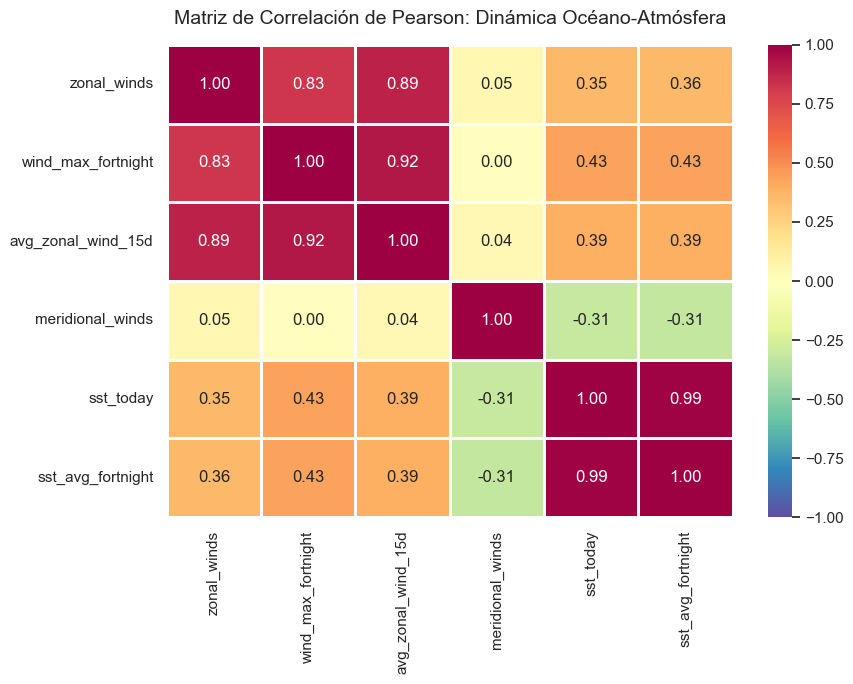

In [ ]:
#1. Seleccionar únicamente las columnas físicas reales

columnas_fisicas = [
    'zonal_winds',
    'wind_max_fortnight',
    'avg_zonal_wind_15d',
    'meridional_winds',
    'sst_today',
    'sst_avg_fortnight',
]

# 2. Calcular la matriz de Pearson
matriz_corr = df_oceanico[columnas_fisicas].corr(method="pearson")

# 3. Configurar el lienzo del gráfico
plt.figure(figsize=(9, 7))

# 4. Dibujar el mapa de calor usando una paleta térmica (Spectral_r)
sns.heatmap(
    matriz_corr,
    annot=True,  # Pinta los números dentro de los cuadrados
    cmap="Spectral_r",  # Rojo para correlación positiva, Azul para negativa
    fmt=".2f",  # Muestra 2 decimales
    linewidths=0.8,
    vmin=-1,
    vmax=1,  # Forzamos los límites matemáticos de Pearson
)

plt.title(
    "Matriz de Correlación de Pearson: Dinámica Océano-Atmósfera",
    fontsize=14,
    pad=15,
)
plt.tight_layout()
plt.show()

Nuestra matriz de correlación demuestra la conexión entre el viento y la temperatura del Pacífico. El indicador atmosférico wind_max_fortnight presenta la mayor correlación con la temperatura del mar (0.43), confirmando que las variaciones del viento actúan como señales tempranas de alerta. Además, la persistencia térmica del océano (0.99) garantiza que, una vez detectado el riesgo en nuestro Dashboard, las empresas pesqueras disponen de una ventana de tiempo operativa fiable para tomar decisiones estratégicas antes de sufrir pérdidas."

Hacemos un mapa de dispersión para visualizar la relación entre la temperatura del mar (sst_today) y el viento máximo (wind_max_fortnight), lo que nos permitirá identificar patrones o tendencias en los datos que podrían estar relacionados con eventos de El Niño.

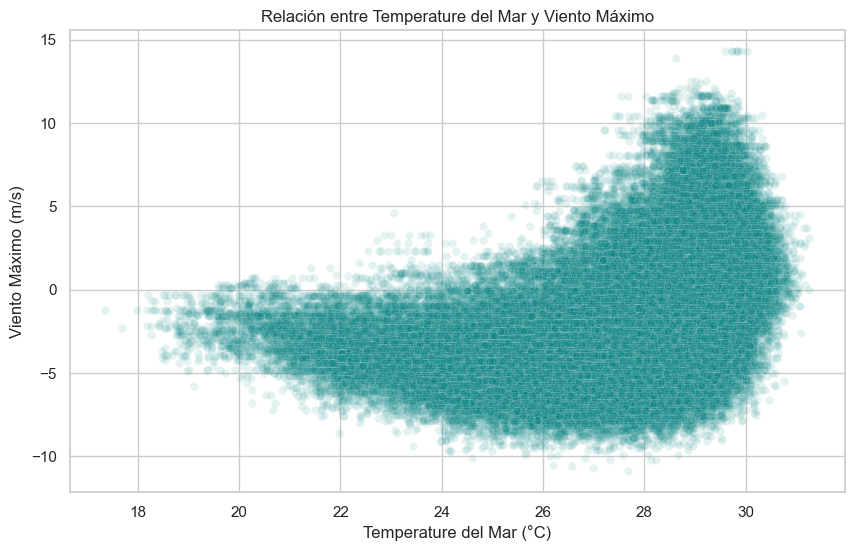

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_oceanico, x='sst_today', y='wind_max_fortnight', alpha=0.1, color='teal')
plt.title('Relación entre Temperature del Mar y Viento Máximo')
plt.xlabel('Temperature del Mar (°C)')
plt.ylabel('Viento Máximo (m/s)')
plt.show()

Este gráfico de dispersión confirma las tendencias que hemos observado hasta ahora. Constatmos que las temperaturas críticas superiores a a la media de 27.72°C (zona derecha) solo ocurren cuando los vientos rompen su patrón habitual y registran valores positivos o cercanos a cero. Esto demuestra visualmente que monitorizar las anomalías del viento en nuestro panel permite anticipar de manera razonable cuándo el mar entrará en la zona de riesgo térmico, dando tiempo a las pesqueras para proteger sus operaciones.